In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [19]:
df = pd.read_csv("C:/Users/User/Desktop/E-COMMERCE PERFORMANCE DASHBOARD/data/superstore.csv", encoding="latin-1")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()


Dataset loaded successfully!
Rows: 9,994
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [20]:
df.shape

(9994, 21)

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [23]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [24]:
df.isnull().sum().sum()

0

In [25]:
df.duplicated().sum()

0

In [26]:
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [27]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date columns converted successfully!")

Date columns converted successfully!


In [28]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [29]:
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


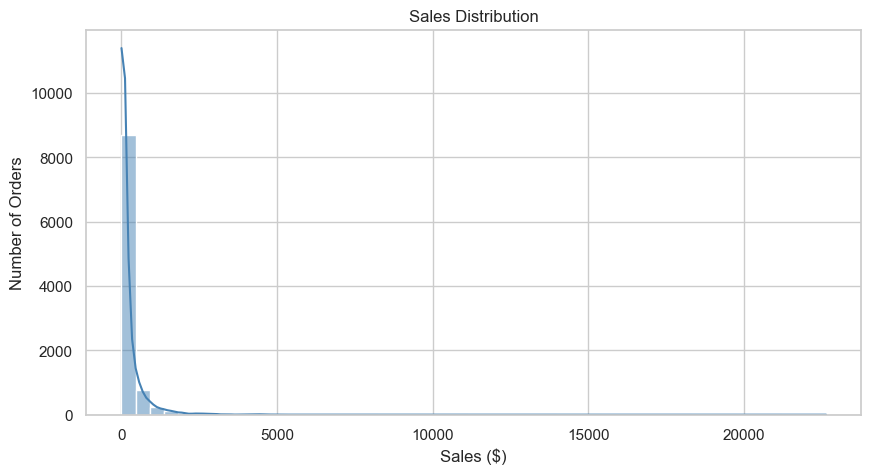

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')

plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")

plt.show()

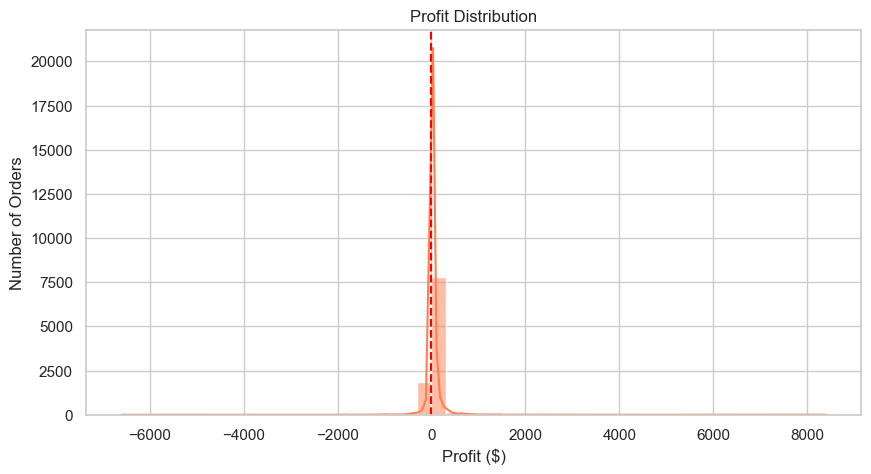

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(df['Profit'], bins=50, kde=True, color='coral')

plt.axvline(0, color='red', linestyle='--')

plt.title("Profit Distribution")
plt.xlabel("Profit ($)")
plt.ylabel("Number of Orders")

plt.show()

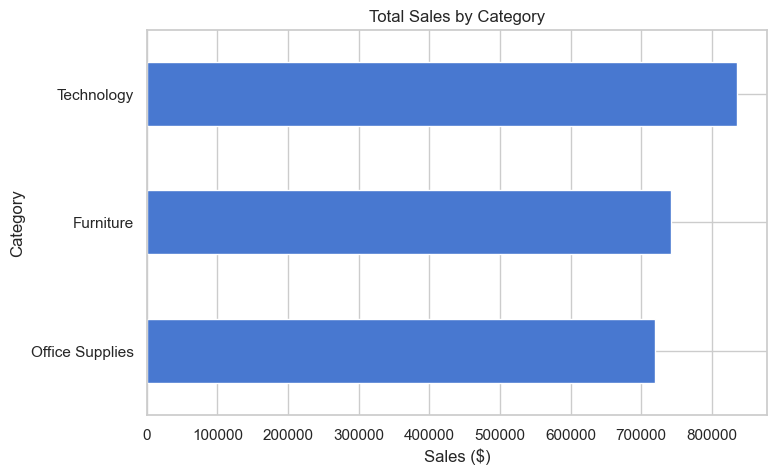

In [32]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))

category_sales.plot(kind='barh')

plt.title("Total Sales by Category")
plt.xlabel("Sales ($)")

plt.show()

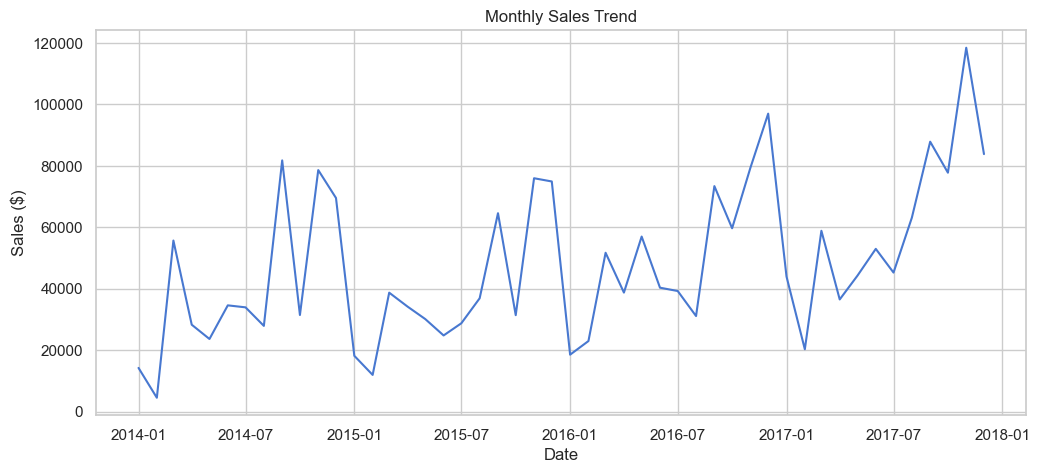

In [33]:
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

monthly['Period'] = pd.to_datetime(
    monthly[['Year','Month']].assign(day=1)
)

plt.figure(figsize=(12,5))

sns.lineplot(data=monthly, x='Period', y='Sales')

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales ($)")

plt.show()

# Exploratory Data Analysis (EDA) Summary

## Dataset Overview
- The Superstore dataset contains 9,994 sales transactions with 21 original columns.
- Additional time-based features (Year, Month, and Quarter) were created to support trend analysis.

## Data Quality
- No missing values were found in the dataset.
- No duplicate records were identified, indicating good data quality.

## Summary Statistics
- The average sales per transaction is $229.86, while the median sales is $54.49, indicating a right-skewed sales distribution.
- The average profit per transaction is $28.66.
- Some transactions generated significant losses, with the minimum profit recorded at -$6,599.98.
- Discounts reach up to 80%, suggesting that discount strategies may influence profitability.

## Key Visual Insights
- Sales are concentrated in a relatively small number of high-value orders.
- The dataset contains both profitable and loss-making transactions.
- Monthly sales show an overall upward trend from 2014 to 2017.
- Sales fluctuate across months, indicating seasonal demand patterns.
- The highest sales performance occurs toward the end of the dataset.

## Conclusion
The dataset is clean and suitable for further analysis. The next phase will focus on data cleaning, SQL analysis, KPI calculation, and identifying business insights for dashboard development.